# Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data_path = '../changedData/cleaned_data/'

In [7]:
dam_data = pd.read_parquet(f'{data_path}dam.parquet')
rtm_data = pd.read_parquet(f'{data_path}rtm.parquet')
weather_data = pd.read_parquet(f'{data_path}weather.parquet')

In [9]:
dam_data.head()

,interval_end_utc,market,location,location_type,lmp,energy,congestion,loss,year
0,2023-01-01 01:00:00+00:00,DAY_AHEAD_HOURLY,MINN.HUB,Hub,35.18,35.74,0.11,-0.67,2023
1,2023-01-01 02:00:00+00:00,DAY_AHEAD_HOURLY,MINN.HUB,Hub,33.14,33.70,0.08,-0.64,2023
2,2023-01-01 03:00:00+00:00,DAY_AHEAD_HOURLY,MINN.HUB,Hub,29.58,32.06,0.04,-2.52,2023
3,2023-01-01 04:00:00+00:00,DAY_AHEAD_HOURLY,MINN.HUB,Hub,27.03,29.64,-0.44,-2.17,2023
4,2023-01-01 05:00:00+00:00,DAY_AHEAD_HOURLY,MINN.HUB,Hub,26.86,29.70,-0.36,-2.48,2023


In [10]:
rtm_data.head()

,interval_end_utc,market,location,location_type,lmp,energy,congestion,loss,year
0,2023-03-24 20:05:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,23.07,25.67,-1.86,-0.74,2023
1,2023-03-25 01:05:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,25.06,25.29,-0.59,0.36,2023
2,2023-03-25 01:10:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,25.02,24.55,-0.14,0.61,2023
3,2023-03-25 01:15:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,24.79,24.47,-0.51,0.83,2023
4,2023-03-25 01:20:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,24.32,24.03,-0.45,0.74,2023


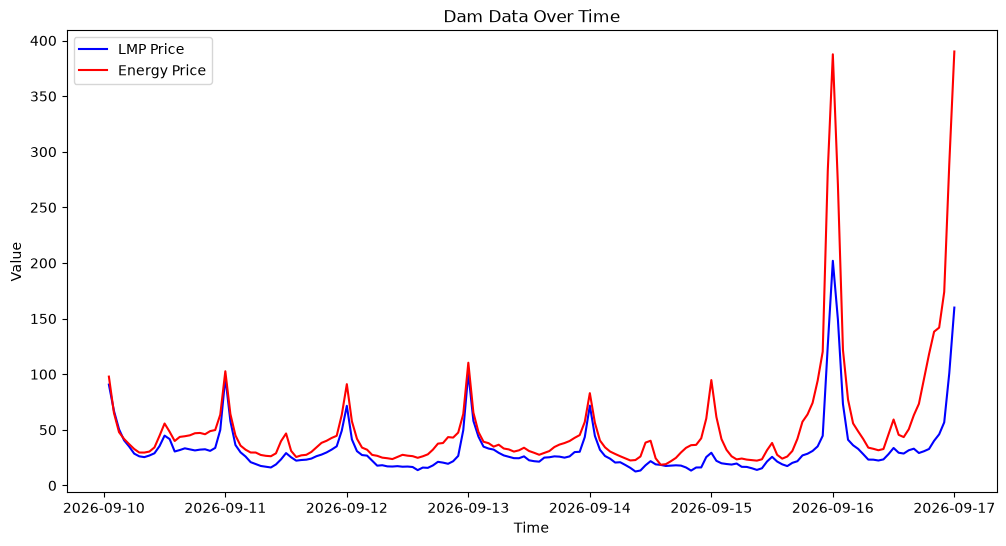

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(
    dam_data.tail(7*24)['interval_end_utc'], 
    dam_data.tail(7*24)['lmp'], 
    label='LMP Price', 
    color='blue')
plt.plot(
    dam_data.tail(7*24)['interval_end_utc'], 
    dam_data.tail(7*24)['energy'], 
    label='Energy Price', 
    color='red'
)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Dam Data Over Time')
plt.legend()
plt.show()

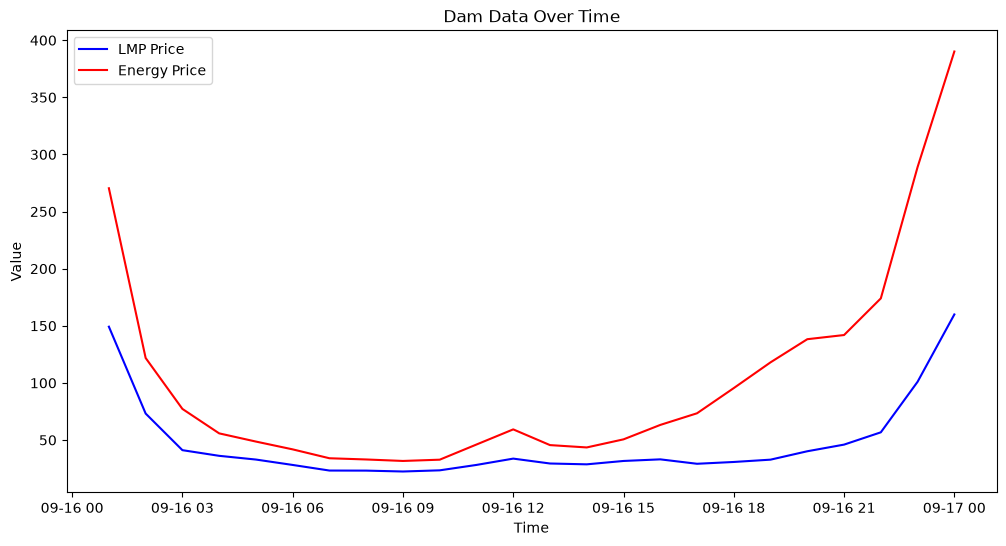

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(
    dam_data.tail(24)['interval_end_utc'], 
    dam_data.tail(24)['lmp'], 
    label='LMP Price', 
    color='blue')
plt.plot(
    dam_data.tail(24)['interval_end_utc'], 
    dam_data.tail(24)['energy'], 
    label='Energy Price', 
    color='red'
)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Dam Data Over Time')
plt.legend()
plt.show()

In [8]:
weather_data.head()

,interval_start_utc,interval_end_utc,publish_time_utc,north_wind,central_wind,south_wind,miso_wind,north_solar,central_solar,south_solar,miso_solar
1993,2023-03-25 01:00:00+00:00,2023-03-25 02:00:00+00:00,2023-03-23 20:15:12+00:00,5416.1,4504.7,0.0,9920.8,3.9,1.0,1.2,6.1
1994,2023-03-25 02:00:00+00:00,2023-03-25 03:00:00+00:00,2023-03-23 20:15:12+00:00,6123.7,4687.2,0.0,10810.9,0.0,0.0,0.0,0.0
1995,2023-03-25 03:00:00+00:00,2023-03-25 04:00:00+00:00,2023-03-23 20:15:12+00:00,6509.5,4884.8,0.0,11394.3,0.0,0.0,0.0,0.0
1996,2023-03-25 04:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-23 20:15:12+00:00,6255.9,5040.3,0.0,11296.2,0.0,0.0,0.0,0.0
1997,2023-03-25 05:00:00+00:00,2023-03-25 06:00:00+00:00,2023-03-23 20:15:12+00:00,5599.5,4986.2,0.0,10585.7,0.0,0.0,0.0,0.0


# Looking at Outage

In [9]:
outage_df = pd.read_parquet(f'{data_path}outage.parquet')
outage_df.head()

,interval_start_utc,interval_end_utc,publish_time_utc,region,derated_outages_mw,forced_outages_mw,planned_outages_mw,unplanned_outages_mw,year
2268,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-21 05:00:00+00:00,Central,1619,1653,18499,40.0,2023
2269,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-21 05:00:00+00:00,MISO,2946,2002,33775,2933.0,2023
2270,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-21 05:00:00+00:00,North,374,135,2879,271.0,2023
2271,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-21 05:00:00+00:00,South,953,214,12397,2622.0,2023
2272,2023-03-24 05:00:00+00:00,2023-03-25 05:00:00+00:00,2023-03-22 05:00:00+00:00,Central,1844,1951,18476,509.0,2023


In [10]:
outage_df.columns

Index(['interval_start_utc', 'interval_end_utc', 'publish_time_utc', 'region',
       'derated_outages_mw', 'forced_outages_mw', 'planned_outages_mw',
       'unplanned_outages_mw', 'year'],
      dtype='object')